In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import numpy as np

numpy_array = np.loadtxt('0_and_1.csv', delimiter=',', skiprows=1)

print(numpy_array.shape)

(8816, 785)


In [ ]:
# Separate the first column (labels) from the rest of the data
labels = numpy_array[:, 0].reshape(-1, 1).T
data = numpy_array[:, 1:].T

print(labels)
print(labels.shape)
print(data)
print(data.shape)

[[1. 0. 1. ... 1. 0. 1.]]
(1, 8816)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
(784, 8816)


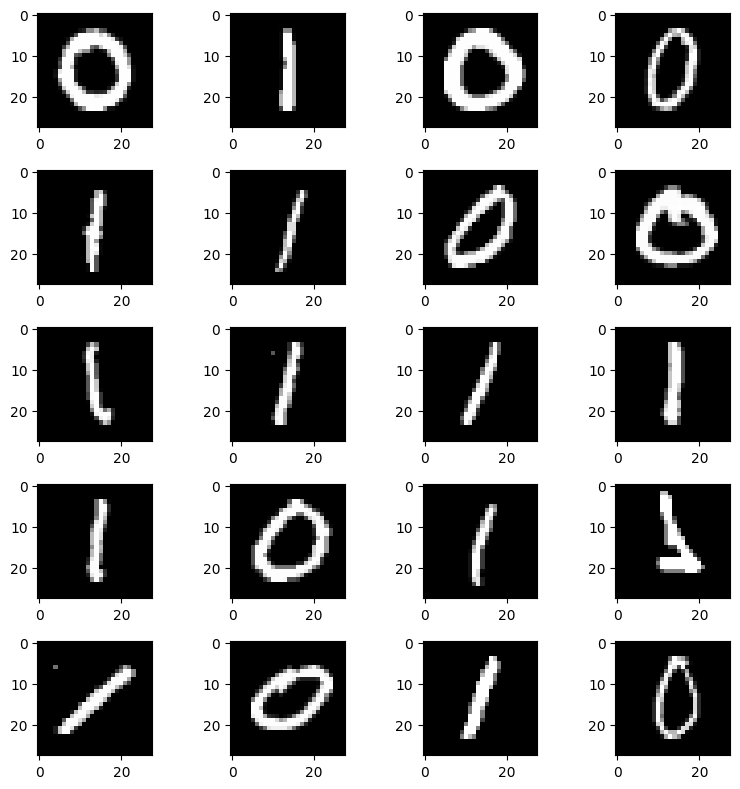

In [ ]:
import matplotlib.pyplot as plt


fig = plt.figure(figsize=(8, 8))
columns = 4
rows = 5
for i in range(1, columns * rows + 1):
    X1 = data[:, i]
    X1 = X1.reshape(28, 28)
    fig.add_subplot(rows, columns, i)
    plt.imshow(X1, cmap='gray')

plt.tight_layout()
plt.show()

In [ ]:
def sigmoid(x, derivative=False):
  f = 1 / (1 + np.exp(-x))
  if derivative:
      return f * (1 - f)
  return 1 / (1 + np.exp(-x))

In [ ]:
print(sigmoid(0))                   # Output: 0.5
print(sigmoid(0, derivative=True))  # Output: 0.25

0.5
0.25


In [ ]:
def network_architecture(X, Y):
  n_x = data.shape[0]
  n_h = 10
  n_y = 1
  return (n_x, n_h, n_y)

n_x, n_h, n_y = network_architecture(data, labels)

# Print the number of nodes in each layer
print("Number of nodes in input layer (n_x):", n_x)
print("Number of nodes in hidden layer (n_h):", n_h)
print("Number of nodes in output layer (n_y):", n_y)

Number of nodes in input layer (n_x): 784
Number of nodes in hidden layer (n_h): 10
Number of nodes in output layer (n_y): 1


In [ ]:
def define_network_parameters(n_x, n_h, n_y):
    W1 = np.random.randn(n_h, n_x) * 0.01
    b1 = np.zeros((n_h, 1))

    W2 = np.random.randn(n_y, n_h) * 0.01
    b2 = np.zeros((n_y, 1))

    parameters = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

    return parameters

In [ ]:
n_x, n_h, n_y = network_architecture(data, labels)

params = define_network_parameters(n_x, n_h, n_y)
print(params['b1'])
print(params['b2'])


[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]
[[0.]]


In [ ]:
def forward_propagation(X, params):
    # Calculate the weighted sum and apply activation function for the first layer
    Z1 = params['W1'].dot(X) + params['b1']
    A1 = sigmoid(Z1)

    # Calculate the weighted sum and apply activation function for the second layer
    Z2 = params['W2'].dot(A1) + params['b2']
    A2 = sigmoid(Z2)

    # Return the calculated intermediate results
    return {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}

In [ ]:
# Perform forward propagation
refor = forward_propagation(data, params)

# Print the shapes of the intermediate variables
print("Z1", refor['Z1'].shape)
print("A1", refor['A1'].shape)
print("Z2", refor['Z2'].shape)
print("A2", refor['A2'].shape)

Z1 (10, 8816)
A1 (10, 8816)
Z2 (1, 8816)
A2 (1, 8816)


In [ ]:
def backward_propagation(params, activations, X, Y):
    """
    Compute the derivatives of the loss with respect to the parameters using backpropagation.

    :param params: Dictionary containing the current parameters.
    :param activations: Dictionary containing the intermediate activations during forward propagation.
    :param X: Input data.
    :param Y: True labels.
    :return: Dictionary containing the derivatives of the loss with respect to the parameters.
    """
    m = X.shape[1]  # Number of training examples

    # Output layer
    dZ2 = sigmoid(activations["Z2"], derivative=True) * (activations["A2"] - Y)
    dW2 = 1 / m * dZ2.dot(activations["A1"].T)
    db2 = 1 / m * np.sum(dZ2)

    # Hidden layer
    dZ1 = sigmoid(activations["Z1"], derivative=True) * params["W2"].T.dot(dZ2)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

def update_parameters(params, derivatives, alpha=0.1):
    """
    Update the parameters using gradient descent.

    :param params: Dictionary containing the current parameters.
    :param derivatives: Dictionary containing the derivatives of the loss with respect to the parameters.
    :param alpha: Learning rate.
    :return: Updated parameters.
    """
    params['W1'] = params['W1'] - alpha * derivatives['dW1']
    params['b1'] = params['b1'] - alpha * derivatives['db1']
    params['W2'] = params['W2'] - alpha * derivatives['dW2']
    params['b2'] = params['b2'] - alpha * derivatives['db2']
    return params

In [ ]:
# Update the parameters using gradient descent and print the updated parameters

# Calculate the derivatives using backward propagation
derivatives = backward_propagation(params, refor, data, labels)
params = update_parameters(params, derivatives)

# Print the updated parameters
print(params)


{'W1': array([[-1.36024450e-02, -3.16941122e-03,  8.56451397e-04, ...,
         2.11218830e-03,  2.00397326e-02, -1.75792918e-02],
       [-6.57739092e-04, -1.60323242e-04, -1.22833814e-02, ...,
        -1.26219722e-03, -6.45495489e-03, -1.88127177e-02],
       [-7.53346768e-05, -2.36382076e-02,  8.46288218e-03, ...,
        -7.99991816e-03, -1.30564913e-03, -1.48652179e-02],
       ...,
       [-1.15701508e-03,  4.30196095e-03, -9.61031592e-03, ...,
        -2.81736629e-03,  1.42158878e-02, -1.07420654e-02],
       [ 2.01837205e-03,  1.89554986e-02, -1.41624337e-03, ...,
         1.91700015e-02,  8.77764477e-05, -1.91395144e-02],
       [ 2.94572535e-03,  8.19052744e-03, -9.08075638e-03, ...,
         5.47044906e-03,  1.75777936e-03, -3.27704792e-03]]), 'b1': array([[5.17211937e-06],
       [5.17211937e-06],
       [5.17211937e-06],
       [5.17211937e-06],
       [5.17211937e-06],
       [5.17211937e-06],
       [5.17211937e-06],
       [5.17211937e-06],
       [5.17211937e-06],
    

In [ ]:
def compute_error(Predicted, Actual):
    """
    Compute the mean squared error between predicted values and actual values.

    :param Predicted: Predicted values.
    :param Actual: Actual values.
    :return: Mean squared error.
    """
    mse = np.mean((Predicted - Actual) ** 2)
    return mse

In [ ]:
def neural_network(X, Y, num_iterations=10):
    """
    Train a neural network model using gradient descent.

    :param X: Input data.
    :param Y: Target data.
    :param num_iterations: Number of iterations for training.
    :return: Trained parameters and cost history.
    """

    # Initialize parameters

    n_x, n_h, n_y = network_architecture(X, Y)
    params = define_network_parameters(n_x, n_h, n_y)
    cost_history = []

    for _ in range(num_iterations):


        # Forward propagation
        activations = forward_propagation(X, params)

        # Compute the error

        error = compute_error(activations['A2'], Y)
        cost_history.append(error)

        # Backward propagation
        derivatives = backward_propagation(params, activations, X, Y)

        # Update parameters
        params = update_parameters(params, derivatives, 0.5)

    return params, cost_history


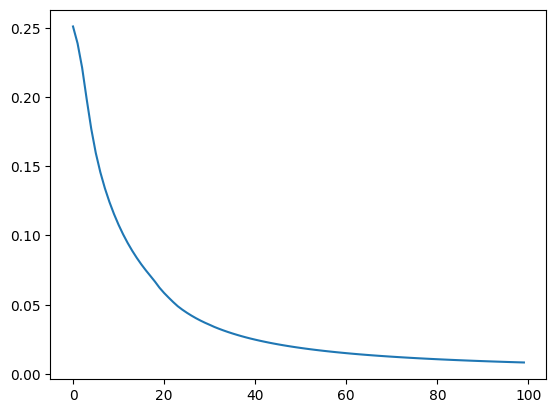

In [ ]:
model, cost = neural_network(data, labels, num_iterations=100)

plt.plot(cost)
plt.show()

In [ ]:
def predict(parameters, X):
    # Perform forward propagation to get the results
    results = forward_propagation(X, parameters)

    # Round the predictions to 0 or 1
    predictions = np.around(results['A2'])

    return predictions

# Make predictions using the trained model
predictions = predict(model, data)

In [ ]:

Error = []

predictions = predictions.flatten()
labels = labels.flatten()
for i in range(len(predictions)):
  if predictions[i] != labels[i]:
    Error.append(i)
print("Indices of misclassified examples:", Error)
# Calculate the accuracy by subtracting the ratio of misclassified examples from 1 and multiplying by 100
accuracy = ((data.shape[0] - len(Error)) / data.shape[0]) * 100

# Print the accuracy as a percentage
print("Accuracy: {:f}%".format(accuracy))

Indices of misclassified examples: [332, 1364, 7653]
Accuracy: 99.617347%


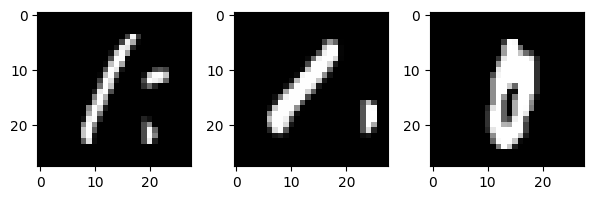

In [ ]:
import matplotlib.pyplot as plt

# Display misclassified images
fig = plt.figure(figsize=(8, 8))
columns = 4
rows = int(np.ceil(len(Error) / columns)) # Calculate rows needed based on number of errors
for i, error_index in enumerate(Error):
    X_error = data[:, error_index]
    X_error = X_error.reshape(28, 28)
    fig.add_subplot(rows, columns, i + 1)
    plt.imshow(X_error, cmap='gray')

plt.tight_layout()
plt.show()